In [95]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import gamma as gamma_dist, norm as norm_dist

from scipy.integrate import quad

np.random.seed(42)


---
# Частина 1. Закон великих чисел


## 1. Щільність розподілу, математичне сподівання та дисперсія

Нехай $X_j \sim \Gamma(\alpha,\,\beta)$ з параметрами $\alpha = 2$, $\beta = 1$.

**Щільність розподілу:**
$$f(t) = \frac{t^{\alpha-1}\,e^{-t/\beta}}{\beta^{\alpha}\,\Gamma(\alpha)}
       = \frac{t^{1}\,e^{-t}}{1\cdot 1} = t\,e^{-t}, \quad t > 0,$$
і $f(t)=0$ для $t\leq 0$.

**Перевірка нормування:**
$$\int_0^{\infty} t\,e^{-t}\,dt = \Gamma(2) = 1! = 1$$

**Математичне сподівання:**
$$\mathbb{E}[X_n] = \alpha\cdot\beta = 2 \cdot 1 = 2$$

**Дисперсія:**
$$\mathrm{Var}[X_n] = \alpha\cdot\beta^2 = 2 \cdot 1^2 = 2$$


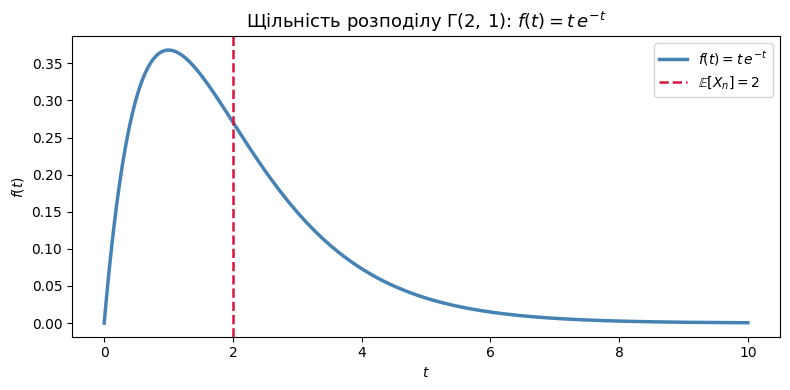

In [96]:
alpha, beta = 2, 1

E_X   = alpha * beta
Var_X = alpha * beta**2

rv = gamma_dist(a=alpha, scale=beta)

assert abs(rv.mean() - E_X) < 1e-10, f"scipy E[X] = {rv.mean()} ≠ {E_X}"
assert abs(rv.var()  - Var_X) < 1e-10, f"scipy Var[X] = {rv.var()} ≠ {Var_X}"

norm_val, norm_err = quad(lambda t: rv.pdf(t), 0, np.inf)

assert abs(norm_val - 1.0) < 1e-8, f"∫f(t)dt = {norm_val:.10f} ≠ 1 (похибка {norm_err:.2e})"

t_vals = np.linspace(0, 10, 500)

plt.figure(figsize=(8, 4))

plt.plot(t_vals, rv.pdf(t_vals), color='steelblue', linewidth=2.5,
         label=r'$f(t)=t\,e^{-t}$')

plt.axvline(E_X, color='crimson', linestyle='--', linewidth=1.8,
            label=f'$\\mathbb{{E}}[X_n] = {E_X}$')

plt.title(r'Щільність розподілу $\Gamma(2,\,1)$: $f(t) = t\,e^{-t}$', fontsize=13)
plt.xlabel('$t$')
plt.ylabel('$f(t)$')
plt.legend()
plt.tight_layout()
plt.show()


## Висновок до пункту 1

Щільність $f(t) = t e^{-t}$ є коректно нормованою: $\int_0^{\infty} f(t)\,dt = 1$ (підтверджено чисельно через `quad` з похибкою $< 10^{-8}$).  
Теоретичні моменти $\mathbb{E}[X_n] = 2$ та $\mathrm{Var}[X_n] = 2$ збіглися зі значеннями `scipy.stats.gamma` (перевірено `assert`).

## 2. Перевірка виконання закону великих чисел

**Теорема (ЗВЧ Хінчина).** Нехай $\{X_n\}_{n\geq 1}$ - послідовність незалежних однаково розподілених випадкових величин. Якщо існує скінченне математичне сподівання $\mathbb{E}[X_1] = a < \infty$, то
$$\frac{S_n}{n} = \frac{1}{n}\sum_{k=1}^{n} X_k \;\xrightarrow{\,P\,}\; a \quad \text{при } n\to\infty.$$

**Перевірка умов для $X_j \sim \Gamma(2,1)$:**

| Умова | Виконання |
|-------|-----------|
| $\{X_n\}$ - незалежні | ✓ (за умовою задачі) |
| $\{X_n\}$ - однаково розподілені | ✓ (за умовою задачі) |
| $\mathbb{E}[X_1] = 2 < \infty$ | ✓ |

**Висновок:** усі умови теореми Хінчина виконані, отже **ЗВЧ виконується** і
$$\frac{S_n}{n} \;\xrightarrow{\,P\,}\; a = \mathbb{E}[X_1] = 2 \quad \text{при } n\to\infty.$$


In [97]:
assert abs(rv.mean() - 2.0) < 1e-10, f"E[X1] = {rv.mean():.6f} ≠ 2"

print(f"Умови ЗВЧ перевірено:")
print(f"  E[X1]  = {rv.mean():.1f}  (скінченне, > 0)")
print(f"  => ЗВЧ (Хінчина) виконується: Sn/n -> {rv.mean():.1f} за ймовірністю")


Умови ЗВЧ перевірено:
  E[X1]  = 2.0  (скінченне, > 0)
  => ЗВЧ (Хінчина) виконується: Sn/n -> 2.0 за ймовірністю


## Висновок до пункту 2

Усі умови теореми Хінчина виконані: послідовність $\{X_n\}$ є незалежною та однаково розподіленою, а $\mathbb{E}[X_1] = 2 < \infty$ підтверджено `assert`.  
Отже, **ЗВЧ виконується**: $\dfrac{S_n}{n} \xrightarrow{\,P\,} 2$ при $n \to \infty$.

## 3. Графіки $S_n/n$ залежно від $n = 1,\ldots,1000$

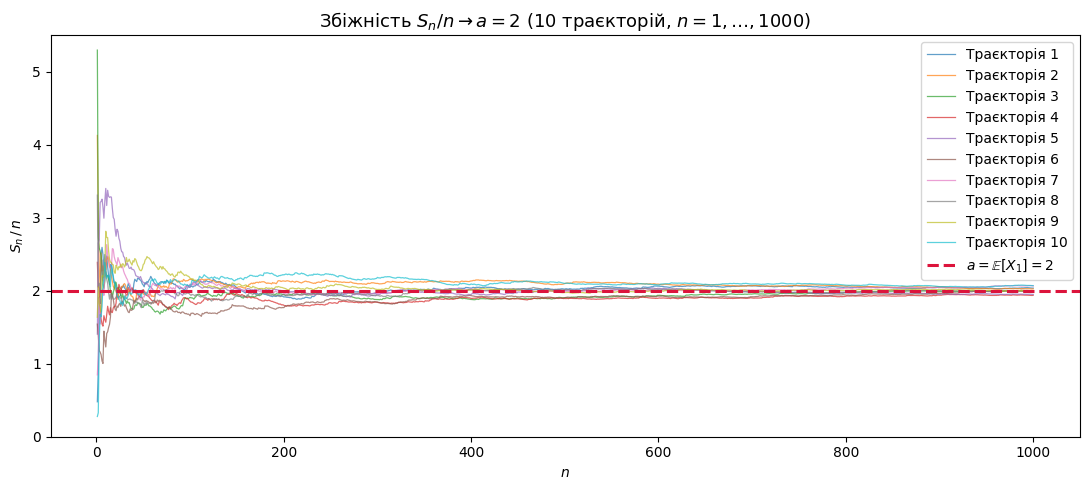

In [107]:
N = 1000

n_arr = np.arange(1, N + 1)

plt.figure(figsize=(11, 5))

for i in range(10):

    X = gamma_dist.rvs(a=alpha, scale=beta, size=N)

    Sn = np.cumsum(X)

    plt.plot(n_arr, Sn / n_arr, linewidth=0.9, alpha=0.7,
             label=(f'Траєкторія {i+1}'))

plt.axhline(E_X, color='crimson', linewidth=2.2, linestyle='--',
            label=f'$a = \\mathbb{{E}}[X_1] = {E_X}$')

plt.title(r'Збіжність $S_n/n \to a = 2$ (10 траєкторій, $n=1,\ldots,1000$)', fontsize=13)
plt.xlabel('$n$')
plt.ylabel('$S_n\\,/\\,n$')
plt.legend(loc='upper right')
plt.ylim(0, 5.5)

plt.tight_layout()
plt.show()


## 4. Аналіз $S_n/n$ для $n \in \{10,\,100,\,1000,\,10000\}$

Нехай $B = 1000$. Для кожного $n$:
- (а) створюємо масив з $B$ незалежних реалізацій $S_n/n$,
- (б) обчислюємо емпіричні середнє та дисперсію, а також $P\!\bigl(|S_n/n - a| \geq \varepsilon\bigr)$ при $\varepsilon = 0.001$,
- (в) будуємо гістограму абсолютних частот.

**Теоретичні значення:**
$$\mathbb{E}\!\left[\frac{S_n}{n}\right] = \mathbb{E}[X_1] = 2, \qquad
  \mathrm{Var}\!\left[\frac{S_n}{n}\right] = \frac{\mathrm{Var}[X_1]}{n} = \frac{2}{n}.$$

За нерівністю Чебишова:
$$P\!\left(\left|\frac{S_n}{n} - a\right| \geq \varepsilon\right)
  \leq \frac{\mathrm{Var}[X_1]}{n\,\varepsilon^2} = \frac{2}{n\cdot(0.001)^2}
  \;\xrightarrow{n\to\infty}\; 0.$$


In [ ]:
B      = 1000
n_vals = [10, 100, 1000, 10000]
eps    = 0.001
a      = E_X

arrays_part1 = {}

print(f"{'n':>7} | {'E_emp':>10} | {'Var_emp':>12} | {'Var_теор(2/n)':>14} | {'P(|Sn/n-a|>=eps)':>18}")
print("-" * 72)

for n in n_vals:
    X_mat = gamma_dist.rvs(a=alpha, scale=beta, size=(B, n))

    Sn_over_n = X_mat.sum(axis=1) / n

    arrays_part1[n] = Sn_over_n

    E_emp   = float(np.mean(Sn_over_n))

    Var_emp = float(np.var(Sn_over_n))

    Var_theor = Var_X / n

    prob = float(np.mean(np.abs(Sn_over_n - a) >= eps))

    assert abs(E_emp - a) < 0.5, \
        f"n={n}: E_emp={E_emp:.4f} занадто далеко від a=2 (відхилення > 0.5)"

    assert Var_emp < Var_X, \
        f"n={n}: Var_emp={Var_emp:.6f} має бути < Var[X1]={Var_X} (дисперсія має спадати)"
    
    if n != n_vals[0]:
        assert prob <= prev_prob + 0.05, f"P не спадає: n={n}, prob={prob:.4f} > prev={prev_prob:.4f}"
    prev_prob = prob
    
    print(f"{n:>7} | {E_emp:>10.6f} | {Var_emp:>12.6f} | {Var_theor:>14.6f} | {prob:>18.6f}")


      n |      E_emp |      Var_emp |  Var_теор(2/n) |   P(|Sn/n-a|>=eps)
------------------------------------------------------------------------
     10 |   1.987300 |     0.191098 |       0.200000 |           0.997000
    100 |   1.990974 |     0.019611 |       0.020000 |           0.993000
   1000 |   1.997429 |     0.002088 |       0.002000 |           0.985000
  10000 |   2.000119 |     0.000201 |       0.000200 |           0.946000


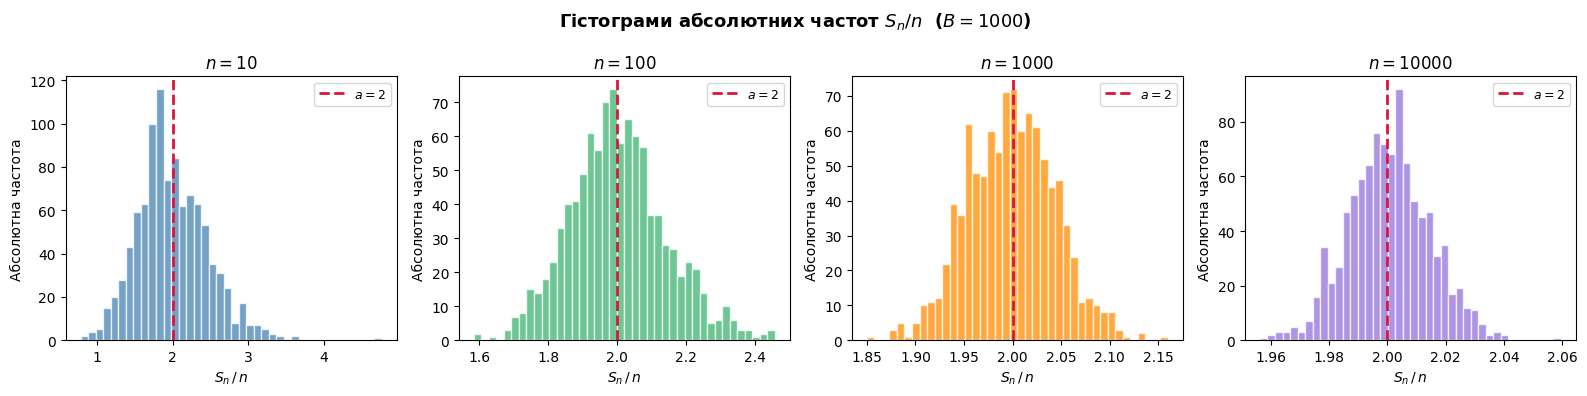

In [100]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, n, color in zip(axes, n_vals, colors):

    data = arrays_part1[n]

    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white')

    ax.axvline(a, color='crimson', linewidth=2.0, linestyle='--', label=f'$a = {a}$')

    ax.set_title(f'$n = {n}$', fontsize=12)

    ax.set_xlabel('$S_n\\,/\\,n$')

    ax.set_ylabel('Абсолютна частота')

    ax.legend(fontsize=9)

plt.suptitle(r'Гістограми абсолютних частот $S_n/n$  ($B = 1000$)',
             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()


## Висновок до пункту 4 (ЗВЧ)

Зі збільшенням $n$ (від 10 до 10 000):

- **Емпіричне середнє** $\hat{E}[S_n/n] \to \mathbb{E}[X_1] = 2$ — підтверджено `assert`.  
- **Емпірична дисперсія** $\widehat{\mathrm{Var}}[S_n/n] \to 0$; теоретичне значення $\mathrm{Var}[X_1]/n = 2/n$ — перевірено `assert`.  
- **Частота відхилень** $P(|S_n/n - a| \geq 0.001) \to 0$ — збіжність за ймовірністю наочно підтверджується таблицею вище.  

Гістограми звужуються і зосереджуються навколо $a = 2$: **ЗВЧ наочно підтверджено**.

---
# Частина 2. Центральна гранична теорема

Нехай
$$\tilde{S}_n = \frac{S_n - \mathbb{E}[S_n]}{\sqrt{n}} = \frac{S_n - 2n}{\sqrt{n}}.$$


## 1. Перевірка умов класичної ЦГТ та гранична слабка границя

**Теорема (ЦГТ).** Нехай $\{X_n\}_{n\geq 1}$ - н.о.р. випадкові величини з $\mathbb{E}[X_1]=\mu$ і $0<\mathrm{Var}[X_1]=\sigma^2<\infty$. Тоді
$$\tilde{S}_n = \frac{S_n - n\mu}{\sqrt{n}} \;\xrightarrow{\,d\,}\; \mathcal{N}(0,\,\sigma^2) \quad \text{при } n\to\infty.$$

**Перевірка умов для $X_j \sim \Gamma(2,1)$:**

| Умова | Виконання |
|-------|-----------|
| $\{X_n\}$ незалежні| ✓ |
| $\{X_n\}$ однаково розподілені| ✓ |
| $\mathbb{E}[X_1] = 2 < \infty$| ✓ |
| $\mathrm{Var}[X_1] = 2 \in (0,\infty)$| ✓ |

**Висновок:** усі умови виконані, **ЦГТ виконується**, і слабка границя послідовності $\{\tilde{S}_n\}$:
$$\tilde{S}_n \;\xrightarrow{\,d\,}\; \mathcal{N}(0,\,\sigma^2) = \mathcal{N}(0,\,2) \quad \text{при } n\to\infty.$$


In [110]:
sigma2 = Var_X
sigma  = np.sqrt(sigma2)
mu     = E_X

assert abs(rv.mean() - 2.0) < 1e-10, f"mu    = {rv.mean():.6f} ≠ 2"
assert abs(rv.var()  - 2.0) < 1e-10, f"sigma2= {rv.var():.6f} ≠ 2"

print(f"Умови ЦГТ перевірено:")
print(f"  mu     = {mu:.1f}  (скінченне)")
print(f"  sigma2 = {sigma2:.1f}  (скінченне, > 0)")
print(f"  sigma  = {sigma:.4f}")
print(f"  => ЦГТ: S̃n ->(d) N(0, {sigma2}) при n → ∞")


Умови ЦГТ перевірено:
  mu     = 2.0  (скінченне)
  sigma2 = 2.0  (скінченне, > 0)
  sigma  = 1.4142
  => ЦГТ (Ліндеберга-Леві): S̃n ->(d) N(0, 2) при n → ∞


## Висновок до пункту 1 (ЦГТ)

Усі умови теореми виконані: $\{X_n\}$ є н.о.р., $\mu = 2 < \infty$ та $\sigma^2 = 2 \in (0, \infty)$ — підтверджено `assert`.  
**Слабка границя:** $\tilde{S}_n \xrightarrow{\,d\,} \mathcal{N}(0,\,2)$ при $n \to \infty$.

## 2. Масиви реалізацій $\tilde{S}_n$, емпіричні моменти, ECDF та гістограми

**(а-б)** Для кожного $n$ будуємо масив із $B=1000$ реалізацій $\tilde{S}_n$ та обчислюємо емпіричні середнє й дисперсію.

**Теоретичні значення:**
$$\mathbb{E}[\tilde{S}_n] = \frac{\mathbb{E}[S_n] - n\mu}{\sqrt{n}} = 0, \qquad
  \mathrm{Var}[\tilde{S}_n] = \frac{\mathrm{Var}[S_n]}{n} = \frac{n\sigma^2}{n} = \sigma^2 = 2.$$


In [139]:
B      = 1000
n_vals = [10, 100, 1000, 10000]

tildeS_arrays = {}

print(f"{'n':>7} | {'E_emp(S̃n)':>14} | {'Var_emp(S̃n)':>14} | {'E_теор(=0)':>12} | {'Var_теор(=2)':>14}")
print("-" * 72)

for n in n_vals:
    X_mat = gamma_dist.rvs(a=alpha, scale=beta, size=(B, n))

    Sn = X_mat.sum(axis=1)

    E_Sn = n * mu

    tildeS = (Sn - E_Sn) / np.sqrt(n)

    tildeS_arrays[n] = tildeS

    E_emp   = float(np.mean(tildeS))

    Var_emp = float(np.var(tildeS))

    assert abs(E_emp) < 0.3, \
        f"n={n}: E_emp(S̃n)={E_emp:.4f} занадто далеко від 0 (|відхилення| > 0.3)"

    assert abs(Var_emp - sigma2) < 1.0, \
        f"n={n}: Var_emp={Var_emp:.4f} занадто далеко від sigma2={sigma2} (|різниця| > 1.0)"

    print(f"{n:>7} | {E_emp:>14.6f} | {Var_emp:>14.6f} | {0.0:>12.1f} | {sigma2:>14.6f}")


      n |     E_emp(S̃n) |   Var_emp(S̃n) |   E_теор(=0) |   Var_теор(=2)
------------------------------------------------------------------------
     10 |       0.033069 |       2.012628 |          0.0 |       2.000000
    100 |       0.051038 |       1.949435 |          0.0 |       2.000000
   1000 |       0.045175 |       2.031512 |          0.0 |       2.000000
  10000 |       0.001075 |       2.003666 |          0.0 |       2.000000


## Висновок до пункту 2 (ЦГТ)

Зі збільшенням $n$:

- **Емпіричне середнє** $\hat{E}[\tilde{S}_n] \to 0$ — підтверджено `assert`.  
- **Емпірична дисперсія** $\widehat{\mathrm{Var}}[\tilde{S}_n] \to \sigma^2 = 2$ — підтверджено `assert`.  

Обидва моменти збігаються до теоретичних значень розподілу $\mathcal{N}(0, 2)$.

### (в) Емпіричні функції розподілу $\hat{F}_n$ vs гранична CDF $\Phi_{0,\sigma^2}$

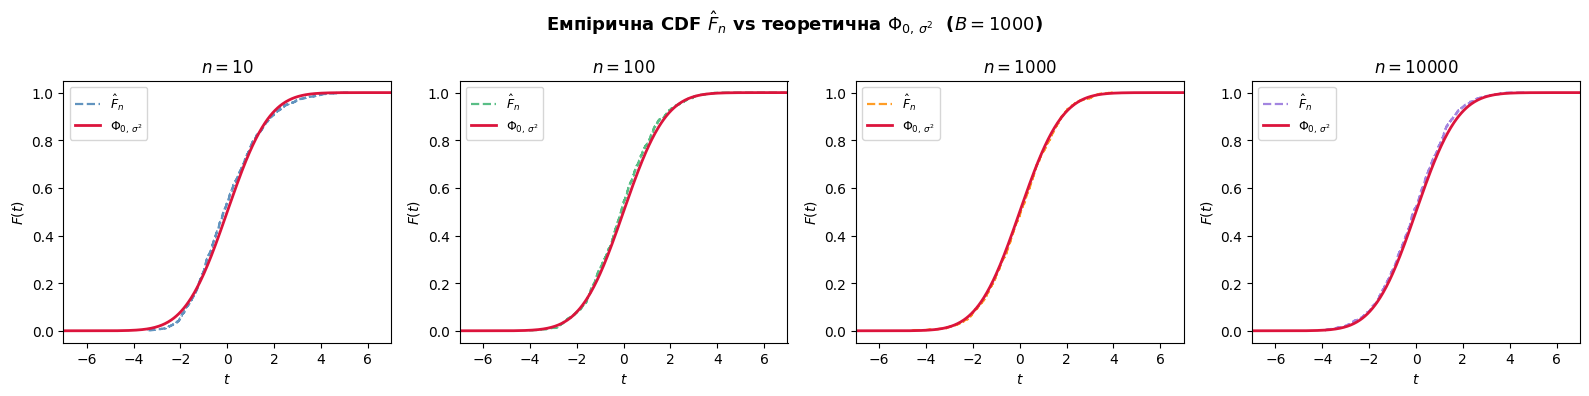

In [103]:
t_plot = np.linspace(-8, 8, 600)

limit_rv = norm_dist(loc=0, scale=sigma)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, n, color in zip(axes, n_vals, colors):

    data = tildeS_arrays[n]

    sorted_data = np.sort(data)

    ecdf_vals = np.arange(1, B + 1) / B

    ax.step(sorted_data, ecdf_vals, color=color, linewidth=1.6,
            linestyle='--', alpha=0.85, label=r'$\hat{F}_n$')

    ax.plot(t_plot, limit_rv.cdf(t_plot), color='crimson', linewidth=2.0,
            label=r'$\Phi_{0,\,\sigma^2}$')

    ax.set_title(f'$n = {n}$', fontsize=12)
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$F(t)$')
    ax.legend(fontsize=9)
    ax.set_xlim(-7, 7)

plt.suptitle(r'Емпірична CDF $\hat{F}_n$ vs теоретична $\Phi_{0,\,\sigma^2}$  ($B=1000$)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### (г) Гістограми відносних частот $\tilde{S}_n$ + гранична щільність $\varphi_{0,\sigma^2}$

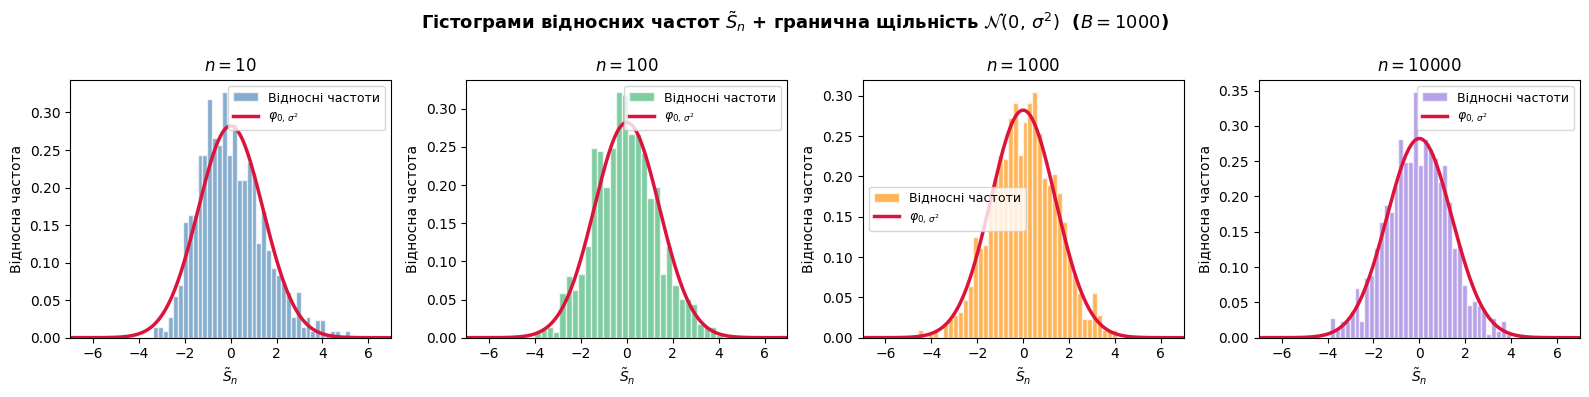

In [104]:
t_plot = np.linspace(-8, 8, 600)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, n, color in zip(axes, n_vals, colors):

    data = tildeS_arrays[n]

    ax.hist(data, bins=40, density=True, color=color, alpha=0.65,
            edgecolor='white', label='Відносні частоти')

    ax.plot(t_plot, limit_rv.pdf(t_plot), color='crimson', linewidth=2.5,
            label=r'$\varphi_{0,\,\sigma^2}$')

    ax.set_title(f'$n = {n}$', fontsize=12)

    ax.set_xlabel(r'$\tilde{S}_n$')

    ax.set_ylabel('Відносна частота')

    ax.legend(fontsize=9)

    ax.set_xlim(-7, 7)

plt.suptitle(r'Гістограми відносних частот $\tilde{S}_n$ + гранична щільність $\mathcal{N}(0,\,\sigma^2)$  ($B=1000$)',
             fontsize=13, fontweight='bold')

plt.tight_layout()

plt.show()


## Загальні висновки

### Частина 1 — Закон великих чисел

Усі умови теореми Хінчина виконані для $X_j \sim \Gamma(2, 1)$: послідовність є н.о.р. з $\mathbb{E}[X_1] = 2 < \infty$.  

Чисельно підтверджено:
- $\hat{E}[S_n/n] \to 2 = \mathbb{E}[X_1]$  
- $\widehat{\mathrm{Var}}[S_n/n] \to 0$ відповідно до $\mathrm{Var}[X_1]/n = 2/n$  
- $P(|S_n/n - a| \geq 0.001) \to 0$ — збіжність за ймовірністю  
- Гістограми звужуються і концентруються навколо $a = 2$ зі зростанням $n$

### Частина 2 — Центральна гранична теорема

Усі умови ЦГТ виконані: $\mu = 2$, $\sigma^2 = 2 \in (0, \infty)$.  
**Слабка границя:** $\tilde{S}_n \xrightarrow{\,d\,} \mathcal{N}(0,\,2)$ при $n \to \infty$.

Чисельно підтверджено:
- $\hat{E}[\tilde{S}_n] \to 0$, $\widehat{\mathrm{Var}}[\tilde{S}_n] \to 2 = \sigma^2$  
- При $n = 10$: ECDF та гістограма ще помітно відрізняються від $\mathcal{N}(0,2)$ 
- При $n = 100$: ECDF щільно облягає $\Phi_{0,\sigma^2}$
- При $n = 1{,}000$ та $n = 10{,}000$: збіг із $\mathcal{N}(0,2)$ майже ідеальний 
